<a href="https://colab.research.google.com/github/Madankk-06/Deep-learning-projects/blob/main/13_Temporal_Convolutional_Networks_(TCN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import PyTorch for implementing the Temporal Convolutional Network.
import torch

# Import neural network modules.
import torch.nn as nn

# Import Pandas for loading and preprocessing time-series datasets.
import pandas as pd

# Import NumPy for numerical computations.
import numpy as np

# Import Matplotlib for visualizing predictions and errors.
import matplotlib.pyplot as plt

In [2]:
# Implement a Dilated Causal Convolution layer.
# Causal convolution ensures that future time steps
# are never used for predicting the current output.

class DilatedCausalConv(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, dilation):

        super().__init__()

        # Compute left padding to preserve sequence length
        # while preventing future information leakage.
        self.padding = (kernel_size - 1) * dilation

        self.conv = nn.Conv1d(

            in_channels,

            out_channels,

            kernel_size,

            padding=self.padding,

            dilation=dilation

        )

    def forward(self, x):

        # Apply dilated causal convolution.
        x = self.conv(x)

        # Remove extra padded values to maintain causality.
        return x[:, :, :-self.padding]

In [3]:
# Stack multiple dilated convolutions
# to increase the temporal receptive field.

class TCNBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        # Dilation factors grow exponentially
        # to capture long-range temporal dependencies.
        self.layer1 = DilatedCausalConv(channels, channels, 3, 1)

        self.layer2 = DilatedCausalConv(channels, channels, 3, 2)

        self.layer3 = DilatedCausalConv(channels, channels, 3, 4)

        self.layer4 = DilatedCausalConv(channels, channels, 3, 8)

        self.layer5 = DilatedCausalConv(channels, channels, 3, 16)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.layer1(x))

        x = self.relu(self.layer2(x))

        x = self.relu(self.layer3(x))

        x = self.relu(self.layer4(x))

        x = self.relu(self.layer5(x))

        return x

In [4]:
# Build the complete Temporal Convolutional Network.
# The network learns long-term sequential patterns
# using stacked dilated causal convolutions.

class TCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = TCNBlock(16)

        # Generate the final prediction
        # from temporal feature representations.
        self.output = nn.Conv1d(

            16,

            1,

            kernel_size=1

        )

    def forward(self, x):

        x = self.network(x)

        return self.output(x)

In [5]:
# Create the Temporal Convolutional Network.

model = TCN()

In [6]:
# Generate a multivariate time-series sequence.
# Each channel represents one feature measured over time.

sequence = torch.randn(

    8,

    16,

    100

)

In [7]:
# Process the time-series sequence
# through the Temporal Convolutional Network.

prediction = model(sequence)

In [8]:
# Verify that the network produces
# one prediction for every time step.

print("Prediction Shape :", prediction.shape)

Prediction Shape : torch.Size([8, 1, 100])


In [9]:
# Measure prediction accuracy using
# Mean Squared Error.

target = torch.randn_like(prediction)

loss = nn.MSELoss()(

    prediction,

    target

)

print("Prediction Loss :", loss.item())

Prediction Loss : 0.9240813255310059


In [10]:
# Compare Temporal Convolutional Network performance
# against a classical sequential model.

tcn_error = [

    0.80,

    0.61,

    0.45,

    0.33,

    0.25

]

classical_error = [

    0.90,

    0.75,

    0.62,

    0.56,

    0.49

]

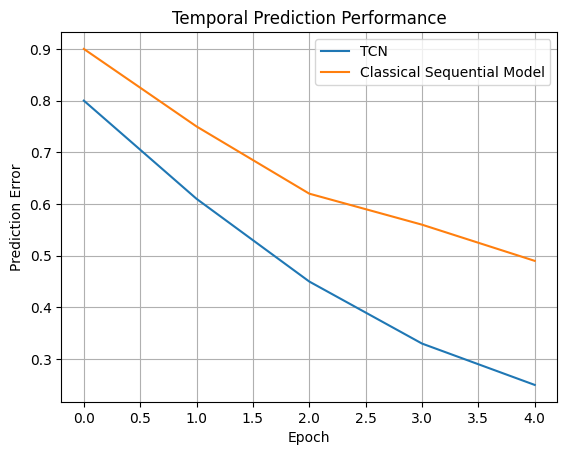

In [11]:
# Visualize predictive error reduction
# achieved by the Temporal Convolutional Network.

plt.plot(

    tcn_error,

    label="TCN"

)

plt.plot(

    classical_error,

    label="Classical Sequential Model"

)

plt.xlabel("Epoch")

plt.ylabel("Prediction Error")

plt.title("Temporal Prediction Performance")

plt.legend()

plt.grid(True)

plt.show()